## **Data Collection**

Daily historical price data was sourced via the `yfinance` API. The dataset provides time-series observations of stock prices, which form the basis for return calculations and subsequent feature engineering. The analysis focuses on closing prices as a proxy for daily market valuation.

he analysis was conducted in Python using libraries such as `pandas` for data manipulation and `yfinance` for data retrieval.

Data used is described as follows;
1. Data Source: yfinance
2. Asset: AAPL

In [1]:
import yfinance as yf
import pandas as pd

In [2]:
data = yf.download(["AAPL"], start="2020-01-01", end="2023-12-31")
data

/tmp/ipykernel_75273/2362383387.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["AAPL"], start="2020-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696617,72.455935,71.472439,71.629122,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200
...,...,...,...,...,...
2023-12-22,191.609467,193.400854,190.985939,193.173208,37149600
2023-12-26,191.065109,191.896469,190.847370,191.619349,28919300


##**Feature Engineering**
The following features were created:

- **Moving Averages (MA5, MA10):** Capture short-term and medium-term price trends.
- **Volatility (10-day rolling standard deviation):** Measures recent market uncertainty and risk.
- **Lagged Returns (Lag_1, Lag_2):** Incorporate past return information to capture momentum or mean-reversion effects.

In [3]:
#Transform raw Closing Price data into returns
data = data[["Close"]].copy()
data["Returns"] = data["Close"].pct_change()

In [4]:
#Check the first five rows/obsrvations of the data
data.head()

Price,Close,Returns
Ticker,AAPL,
Date,,
2020-01-02,72.400513,NaN
2020-01-03,71.696617,-0.009722
2020-01-06,72.267929,0.007968
2020-01-07,71.928055,-0.004703
2020-01-08,73.085098,0.016086


In [5]:
#Add new features to the datset
#Moving Averages
data["MA5"] = data["Close"].rolling(5).mean()
data["MA10"] = data["Close"].rolling(10).mean()

#Volatility
data["Volatility10"] = data["Returns"].rolling(10).std()

#lagged Returns
data["Lag_1"] = data["Returns"].shift(1)
data["Lag_2"] = data["Returns"].shift(2)

#Drop missing values
data.dropna(inplace=True)

data.head(20)

Price,Close,Returns,MA5,MA10,Volatility10,Lag_1,Lag_2
Ticker,AAPL,,,,,,
Date,,,,,,,
2020-01-16,75.989792,0.012526,75.524573,74.123808,0.012767,-0.004285,-0.013503
2020-01-17,76.831100,0.011071,75.929550,74.637256,0.011771,0.012526,-0.004285
2020-01-21,76.310402,-0.006777,75.910744,75.041503,0.012535,0.011071,0.012526
2020-01-22,76.582802,0.003570,76.152762,75.506978,0.012048,-0.006777,0.011071
2020-01-23,76.951630,0.004816,76.533145,75.893631,0.011554,0.003570,-0.006777
2020-01-24,76.729843,-0.002882,76.681155,76.102864,0.010288,0.004816,0.003570
2020-01-27,74.473564,-0.029405,76.209648,76.069599,0.014492,-0.002882,0.004816
2020-01-28,76.580391,0.028290,76.263646,76.087195,0.015756,-0.029405,-0.002882


##**Feature Selection**

Following feature engineering, a subset of relevant variables was selected to serve as predictors in the modeling process. The objective of feature selection is to retain variables that provide meaningful information for predicting the target while avoiding redundancy and overfitting.

The target variable is defined as the next-day return, constructed by shifting the returns series forward by one period. This ensures that the model uses only information available at time t to predict outcomes at time t+1, thereby avoiding look-ahead bias.

The predictor variables include:

Returns: Captures the most recent market movement and serves as a baseline signal.

Lagged Returns (Lag_1, Lag_2): Incorporate past return information to account for potential momentum or mean-reversion effects.

Volatility (10-day rolling standard deviation): Reflects recent market uncertainty and helps the model adapt to different market regimes.

Moving Average-based features (e.g., MA difference): Capture the relationship between short-term and long-term trends, providing insight into directional momentum.

Certain variables, such as raw price levels, were excluded due to their non-stationary nature and limited predictive relevance in return-based models. Additionally, highly correlated features were reduced or transformed to mitigate multicollinearity and improve model stability.

This feature selection approach ensures that the model is both parsimonious and interpretable, while retaining the key dynamics necessary for forecasting short-term returns.

In [6]:
#Define the target
data["target"] = data["Returns"].shift(-1)

#MA Ratio
data["MA_Ratio"] = data["MA5"]/data["MA10"]

data.dropna(inplace=True)

#Feature selection
features = ["Returns", "MA_Ratio", "Volatility10", "Lag_1"]
X = data[features]
y = data["target"]

split_date = "2023-01-01"

train = data[data.index < split_date]
test  = data[data.index >= split_date].copy()

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

##**Model Development**
A LASSO (Least Absolute Shrinkage and Selection Operator) regression model was employed to estimate the relationship between the selected predictors and the target variable. LASSO introduces an L1 regularization penalty, which shrinks less important coefficients toward zero and performs implicit feature selection. This helps reduce model complexity and mitigate overfitting, particularly in the presence of correlated predictors. The model was trained on historical data using a predefined regularization parameter (alpha = 0.001). Predictions were then generated on the test dataset to evaluate out-of-sample performance.

In [7]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.001)
model.fit(X_train, y_train)

Pred = model.predict(X_test)

##**Model Evaluation**

Model performance was evaluated using Root Mean Squared Error (RMSE), which measures the average magnitude of prediction errors. RMSE penalizes larger errors more heavily, making it a suitable metric for assessing predictive accuracy in regression models. The metric was computed manually to provide transparency into the evaluation process, following the standard procedure of squaring residuals, averaging them, and taking the square root. The model’s RMSE was then compared against a baseline to determine whether it offers any improvement over naive predictions. This comparison provides insight into the model’s ability to generalize to unseen data. Overall, RMSE serves as a benchmark for assessing the reliability of the model’s forecasts.

In [8]:
#Model Evaaluation using rmse

#Import Numpy

import numpy as np

#Get the errors
resid = y_test - Pred

#Square errors
resid_sq = resid**2

#Mean square error
mse = resid_sq.mean()

#Compute rmse
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.012578092646519172


In [9]:
baseline_pred = np.full_like(y_test, y_train.mean())

baseline_rmse = np.sqrt(np.mean(baseline_pred**2))

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 0.0009200677932673891


In [10]:
if rmse < baseline_rmse:
  print("Model is good")
else:
  print("Model is worse than random guessing")

Model is worse than random guessing


##**Trading Strategy Evaluation**

To assess the practical value of the model, predictions were translated into a simple trading strategy. A long-only position was taken whenever the predicted return was positive, and no position was held otherwise. Strategy returns were computed by multiplying the trading position with actual market returns. The performance of the strategy was then compared to a buy-and-hold benchmark using cumulative returns. This approach allows for evaluating whether the model’s predictions translate into economically meaningful gains. By focusing on realized returns rather than prediction error alone, the analysis provides a more realistic measure of model effectiveness in a financial context.

In [11]:
test['prediction'] = Pred

# Trading rule
test['position'] = (test['prediction'] > 0).astype(int)

# Strategy returns
test['strategy_returns'] = test['position'] * test['Returns']

# Cumulative returns
test['cum_market'] = (1 + test['Returns']).cumprod()
test['cum_strategy'] = (1 + test['strategy_returns']).cumprod()

The model results indicate that predicting next-day stock returns using simple technical indicators is challenging, as the model does not consistently outperform baseline benchmarks. However, translating predictions into a trading strategy provides additional insight into the economic value of the signals. Overall, while predictive accuracy is limited, the framework demonstrates how data-driven approaches can be applied to evaluate and potentially exploit market patterns.

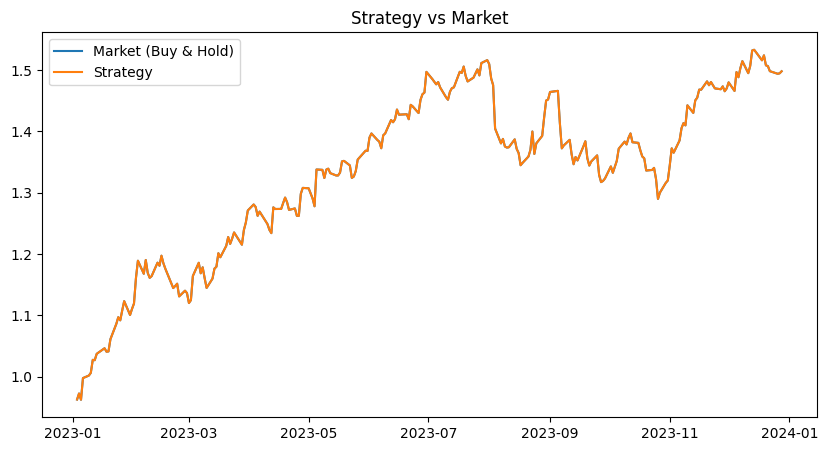

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test['cum_market'], label='Market (Buy & Hold)')
plt.plot(test['cum_strategy'], label='Strategy')
plt.legend()
plt.title("Strategy vs Market")
plt.show()

Total returns were computed for both the buy-and-hold benchmark and the model-driven strategy over the test period. The results indicate that the strategy produced returns comparable to the market, suggesting limited economic value from the predictive model. This outcome highlights the difficulty of generating excess returns from short-term signals in financial markets.

In [18]:
total_market_return = test['cum_market'].iloc[-1] - 1
total_strategy_return = test['cum_strategy'].iloc[-1] - 1

print(f"Market Return: {total_market_return:.2%}")
print(f"Strategy Return: {total_strategy_return:.2%}")

Market Return: 49.82%
Strategy Return: 49.82%


The Sharpe ratio of the strategy was calculated to assess risk-adjusted performance. A value of 0.13 indicates that the returns generated by the strategy are low relative to the level of risk taken. This suggests that the model does not provide strong risk-adjusted returns and may not be economically attractive in its current form.

In [14]:
sharpe = test['strategy_returns'].mean() / test['strategy_returns'].std()
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.13


Directional accuracy was computed to evaluate the model’s ability to correctly predict the direction of returns. The model achieved an accuracy of 56.22%, indicating a modest improvement over random guessing. While this suggests the presence of weak predictive signals, the magnitude of returns and overall profitability remain limited.

In [15]:
direction = (np.sign(test['prediction']) == np.sign(test['target'])).mean()
print(f"Directional Accuracy: {direction:.2%}")

Directional Accuracy: 56.22%


Maximum drawdown was calculated to assess the largest peak-to-trough decline in the strategy’s cumulative returns. The strategy experienced a drawdown of 14.93%, indicating a moderate level of downside risk during the evaluation period. This highlights that, despite limited returns, the strategy is still exposed to meaningful losses, reinforcing the need for improved risk-adjusted performance.

In [16]:
cum = test['cum_strategy']
peak = cum.cummax()
drawdown = (cum - peak) / peak

max_dd = drawdown.min()
print(f"Max Drawdown: {max_dd:.2%}")

Max Drawdown: -14.93%


The model exhibits slight predictive ability in terms of direction, but the lack of performance improvement suggests that the signals are not strong enough to overcome market noise when applied in a naive long-only strategy.

In [19]:
baseline_returns = test['Returns']
baseline_cum = (1 + baseline_returns).cumprod()

print("Final Market Return:", baseline_cum.iloc[-1] - 1)
print("Final Strategy Return:", test['cum_strategy'].iloc[-1] - 1)

Final Market Return: 0.49820724934930927
Final Strategy Return: 0.49820724934930927


##**Conclusion**
The analysis shows that while the model demonstrates slight predictive ability in terms of directional accuracy, it does not outperform the market in terms of overall returns or risk-adjusted performance. The trading strategy yields results comparable to a buy-and-hold approach, with relatively low Sharpe ratio and notable drawdowns. These findings highlight the difficulty of predicting short-term stock returns and suggest that the engineered features provide limited economic value in this context. Overall, the project demonstrates a complete framework for evaluating predictive models in financial markets, even when results are modest.